# Challenge Lab: Module 07 -- Topic Modeling with LDA

**Course:** AI 102: Natural Language-Based Programming Techniques

- **Name:** Reezy Hudson
- **NetID:** rhudso10
- **Section:** 002

---

## Submission Guidelines

### What to Submit:
- This completed notebook with all cells run (use Runtime → Restart and run all)
- All `# TODO:` sections completed with working code
- All reflection questions answered in markdown

### File Naming:
- `LastName_FirstName_M07_TopicModeling.ipynb`

---

## Grading Rubric (100 Points)

| Part | Topic | Points |
|:-----|:------|-------:|
| Part 1 | Setup and Data Loading | -- |
| Part 2 | Text Preprocessing (TODOs 1-2) | 15 pts |
| Part 3 | gensim Dictionary and Corpus (TODOs 3-4) | 15 pts |
| Part 4 | Train the LDA Model (TODO 5) | 10 pts |
| Part 5 | Interpret Topics (TODOs 6-7) | 20 pts |
| Part 6 | Topic Distribution per Document (TODOs 8-9) | 10 pts |
| Part 7 | Coherence Score Comparison (TODO 10) | 15 pts |
| Part 8 | pyLDAvis (TODO 11) | 10 pts |
| Part 9 | Reflection Questions | 5 pts |
| | **Total** | **100 pts** |


## Learning Goals

By the end of this lab, you will be able to:

- Preprocess a real text corpus (CMU Book Summaries from Hugging Face) using `gensim.utils.simple_preprocess`
- Build a gensim **Dictionary and Corpus** from tokenized documents
- Train a **gensim LDA model** to discover hidden topics
- Interpret topics by reading their top keywords and assigning labels
- Use **coherence scores** to compare different topic counts objectively
- Visualize topics interactively using **pyLDAvis**

**Where to look for help:** the in-class workbook and the Module 07 guided lab use the exact same
gensim pipeline. Refer to them whenever you forget syntax.


## Part 1: Setup and Data Loading (provided)

We will use the **CMU Book Summary Dataset** from Hugging Face, which contains **16,559 book plot summaries** scraped from Wikipedia. Each row has the book's **title**, **author**, **publication year**, and a full **summary** describing what happens in the book.


We will use this data to find hidden themes (topics) using **gensim LDA** -- the same library you used in
the in-class workbook and the guided lab.

**Run the next two cells exactly as they are.** They install libraries and load the data into a DataFrame.


In [1]:
# ---- Run this cell as-is ----

# Install gensim 4.3+ and Hugging Face datasets
!pip install -q 'gensim>=4.3' pyLDAvis datasets

import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from datasets import load_dataset

# Download NLTK stopwords for filtering
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

print('Setup complete!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 50.0 MB/s eta 0:00:00
Setup complete!


In [2]:
# ---- Run this cell as-is ----

# Load all 16,559 book plot summaries from Hugging Face
raw_dataset = load_dataset('textminr/cmu-book-summaries', split='train')

# Convert to pandas DataFrame for easier handling
df = raw_dataset.to_pandas()

# Rename 'summary' column to 'text' for consistency with the rest of the lab
df = df.rename(columns={'summary': 'text'})

# Drop any rows with missing summaries
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f'Total books: {len(df)}')
print(f'\nSample of titles in the dataset:')
print(df['title'].head(5).tolist())
print(f'\nFirst book:')
print(f'  Title: {df["title"].iloc[0]}')
print(f'  Author: {df["author"].iloc[0]}')
print(f'  Summary (first 300 chars): {df["text"].iloc[0][:300]}')


README.md:   0%|          | 0.00/505 [00:00<?, ?B/s]

data/train-00000-of-00001-793a356a05565f(…):   0%|          | 0.00/26.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16559 [00:00<?, ? examples/s]

Total books: 16559

Sample of titles in the dataset:
['Animal Farm', 'A Clockwork Orange', 'The Plague', 'An Enquiry Concerning Human Understanding', 'A Fire Upon the Deep']

First book:
  Title: Animal Farm
  Author: George Orwell
  Summary (first 300 chars):  Old Major, the old boar on the Manor Farm, calls the animals on the farm for a meeting, where he compares the humans to parasites and teaches the animals a revolutionary song, 'Beasts of England'. When Major dies, two young pigs, Snowball and Napoleon, assume command and turn his dream into a philo


👀 **Expected:** ~16,559 books loaded with the first 5 titles shown and a preview of the first book's title, author, and summary. Note: dataset download takes 30-60 seconds the first time.


## Part 2: Text Preprocessing (TODOs 1-2) -- 15 pts

Before training a topic model, you need to clean each book summary. We use **`gensim.utils.simple_preprocess`**
(the same function from the guided lab), which lowercases the text, removes punctuation and numbers,
and returns a list of tokens. Then you remove stopwords so they don't dominate the topics.


### TODO 1: Tokenize all book summaries (8 pts)

**Goal:** Apply `simple_preprocess` (with `deacc=True`) to every book summary in `df['text']` and store the
result in a new column called `df['tokens']`. Each entry in the new column should be a list of clean tokens.

**Hint:** You will need to import `simple_preprocess` from `gensim.utils`. Use a `for` loop -- not a list comprehension.

deacc (bool, optional) – Remove accentuation if True.


In [3]:
# ---- TODO 1: Tokenize each book summary with simple_preprocess ----
from gensim.utils import simple_preprocess

tokens_list = []
for text in df["text"]:
    tokens_list.append(simple_preprocess(text, deacc=True))

df["tokens"] = tokens_list


# ---- End TODO 1 ----

# Verify your work
print(f'Number of tokenized summaries: {len(df)}')
print(f'\nFirst 30 tokens of Book 0:')
print(df['tokens'].iloc[0][:30])


Number of tokenized summaries: 16559

First 30 tokens of Book 0:
['old', 'major', 'the', 'old', 'boar', 'on', 'the', 'manor', 'farm', 'calls', 'the', 'animals', 'on', 'the', 'farm', 'for', 'meeting', 'where', 'he', 'compares', 'the', 'humans', 'to', 'parasites', 'and', 'teaches', 'the', 'animals', 'revolutionary', 'song']


👀 **Expected:** A list of 30 lowercase tokens with no punctuation or numbers, e.g.

`['old', 'major', 'the', 'old', 'boar', 'on', 'the', 'manor', 'farm', 'calls', ...]`


### TODO 2: Remove stopwords from each tokenized book summary (7 pts)

**Goal:** Build a stopword list and apply it to every tokenized book summary. Store the result in a list called `data_words`.

#### Why we need MORE than NLTK stopwords

NLTK's default English stopwords (`the`, `and`, `is`, `of`, ...) only catch the most basic filler words. Book plot summaries contain many MORE filler words that aren't on NLTK's list but appear in nearly every summary regardless of genre:

- `book`, `novel`, `story`, `chapter`, `narrator`, `protagonist`, `character`, `tale`
- `man`, `woman`, `boy`, `girl`, `young`, `family`, `life`, `time`, `home`
- `say`, `tell`, `find`, `come`, `take`, `make`, `know`, `think`

If we don't remove these, LDA will produce **garbage topics** where the same generic words show up in every topic. To save you the trouble of guessing which words to add, **we provide the full filler list below** -- just copy it into your code.

**Requirements:**
1. Start with NLTK's English stopwords
2. Extend it with the `heavy_noise` list provided below
3. Use a `for` loop (not a list comprehension) to filter each summary's tokens
4. Store the result in `data_words`

**Hint -- copy this list into your code:**

```python
heavy_noise = [
    # Book/literary words
    'book', 'books', 'novel', 'novels', 'story', 'stories',
    'chapter', 'chapters', 'tale', 'tales', 'narrator', 'protagonist',
    'character', 'characters', 'plot', 'author', 'reader', 'readers',
    # Generic action verbs
    'go', 'goes', 'going', 'gone', 'went',
    'come', 'comes', 'coming', 'came',
    'get', 'gets', 'getting', 'got',
    'take', 'takes', 'taking', 'took', 'taken',
    'make', 'makes', 'making', 'made',
    'see', 'sees', 'seen', 'saw',
    'tell', 'tells', 'told', 'say', 'says', 'said',
    'find', 'finds', 'found', 'know', 'knows', 'knew',
    'try', 'tries', 'tried', 'leave', 'leaves', 'left',
    'use', 'uses', 'used', 'help', 'helps', 'helped',
    'think', 'thinks', 'thought', 'feel', 'feels', 'felt',
    # Generic people references
    'man', 'men', 'woman', 'women', 'people', 'person',
    'boy', 'girl', 'one', 'two', 'three', 'first', 'second',
    # Time and place filler
    'time', 'times', 'day', 'days', 'night', 'year', 'years',
    'home', 'house', 'place', 'way', 'world', 'life',
    # Vague modifiers
    'back', 'next', 'later', 'soon', 'still', 'now', 'then',
    'also', 'even', 'just', 'much', 'many', 'really',
    'would', 'could', 'might', 'may',
    # Generic descriptors
    'new', 'old', 'young', 'good', 'bad', 'big', 'little',
    'thing', 'things', 'something', 'anything', 'nothing',
]
```


In [4]:
# ---- TODO 2: Build stopword list and remove stopwords from each summary ----

# Step 1: Load NLTK English stopwords
stop_words = stopwords.words('english')

heavy_noise = [
    # Book/literary words
    'book', 'books', 'novel', 'novels', 'story', 'stories',
    'chapter', 'chapters', 'tale', 'tales', 'narrator', 'protagonist',
    'character', 'characters', 'plot', 'author', 'reader', 'readers',
    # Generic action verbs
    'go', 'goes', 'going', 'gone', 'went',
    'come', 'comes', 'coming', 'came',
    'get', 'gets', 'getting', 'got',
    'take', 'takes', 'taking', 'took', 'taken',
    'make', 'makes', 'making', 'made',
    'see', 'sees', 'seen', 'saw',
    'tell', 'tells', 'told', 'say', 'says', 'said',
    'find', 'finds', 'found', 'know', 'knows', 'knew',
    'try', 'tries', 'tried', 'leave', 'leaves', 'left',
    'use', 'uses', 'used', 'help', 'helps', 'helped',
    'think', 'thinks', 'thought', 'feel', 'feels', 'felt',
    # Generic people references
    'man', 'men', 'woman', 'women', 'people', 'person',
    'boy', 'girl', 'one', 'two', 'three', 'first', 'second',
    # Time and place filler
    'time', 'times', 'day', 'days', 'night', 'year', 'years',
    'home', 'house', 'place', 'way', 'world', 'life',
    # Vague modifiers
    'back', 'next', 'later', 'soon', 'still', 'now', 'then',
    'also', 'even', 'just', 'much', 'many', 'really',
    'would', 'could', 'might', 'may',
    # Generic descriptors
    'new', 'old', 'young', 'good', 'bad', 'big', 'little',
    'thing', 'things', 'something', 'anything', 'nothing',
]

stop_words.extend(heavy_noise)
stop_words = list(set(stop_words))

# Remove duplicates (provided)
stop_words = list(set(stop_words))
print(f'Total stopwords: {len(stop_words)}')

data_words = []
for token_list in df['tokens']:
    filtered_tokens = []
    for word in token_list:
        # Add word only if it is NOT a stopword
        if word not in stop_words:
            filtered_tokens.append(word)
    data_words.append(filtered_tokens)


# Verify
print(f'Number of cleaned summaries: {len(data_words)}')
print(f'\nFirst 30 tokens of Book 0 after stopword removal:')
print(data_words[0][:30])


Total stopwords: 324
Number of cleaned summaries: 16559

First 30 tokens of Book 0 after stopword removal:
['major', 'boar', 'manor', 'farm', 'calls', 'animals', 'farm', 'meeting', 'compares', 'humans', 'parasites', 'teaches', 'animals', 'revolutionary', 'song', 'beasts', 'england', 'major', 'dies', 'pigs', 'snowball', 'napoleon', 'assume', 'command', 'turn', 'dream', 'philosophy', 'animals', 'revolt', 'drive']


👀 **Expected:** Book 0 should contain only **content words** -- specific names, places, and plot details. No "the", "and", "story", "character", or any of the filler words from `heavy_noise`. Total stopword count should be around **300+**.

`First 30 tokens of Book 0 after stopword removal:
['major', 'boar', 'manor', 'farm', 'calls', 'animals', 'farm', 'meeting', 'compares', 'humans', 'parasites', 'teaches', 'animals', 'revolutionary', 'song', 'beasts', 'england', 'major', 'dies', 'pigs', 'snowball', 'napoleon', 'assume', 'command', 'turn', 'dream', 'philosophy', 'animals', 'revolt', 'drive']`


## Part 3: Build the gensim Dictionary and Corpus (TODOs 3-4) -- 15 pts

Now convert the cleaned text into the data structures gensim needs:

- **Dictionary** -- maps every unique word to an integer ID
- **Corpus** -- each document becomes a list of `(word_id, count)` tuples (bag-of-words)

**This is the same pipeline you used in the guided lab.** Refer back to it for syntax.


### TODO 3: Build the gensim Dictionary (5 pts)

**Goal:** Build a gensim `Dictionary` from `data_words` and store it in a variable called `id2word`.
Then filter out very rare and very common words to keep the vocabulary manageable.

**Hint:** Look up `corpora.Dictionary` in the guided lab. Use `id2word.filter_extremes(no_below=5, no_above=0.5)`
to keep only words that appear in at least 5 summaries and at most 50% of all summaries.


In [5]:
# ---- TODO 3: Build the Dictionary and filter extremes ----
from gensim import corpora

id2word = corpora.Dictionary(data_words)
id2word.filter_extremes(no_below=5, no_above=0.5)


# ---- End TODO 3 ----

# Verify
print(f'Vocabulary size after filtering: {len(id2word)}')
print(f'\nSample words and their IDs:')
for word_id in list(id2word.token2id.values())[:10]:
    print(f'  ID {word_id}: {id2word[word_id]}')


Vocabulary size after filtering: 31087

Sample words and their IDs:
  ID 0: abuse
  ID 1: abuses
  ID 2: account
  ID 3: accusations
  ID 4: accuses
  ID 5: actual
  ID 6: adapt
  ID 7: added
  ID 8: adopt
  ID 9: adopting


👀 **Expected:** Vocabulary size should be in the **5,000-15,000** range after filtering.

`Vocabulary size after filtering: 31087`


### TODO 4: Build the bag-of-words Corpus (10 pts)

**Goal:** Convert every document in `data_words` into a bag-of-words representation using
`id2word.doc2bow()`. Store the result in a list called `bow_corpus`.

**Hint:** Use a `for` loop (not a list comprehension). Each entry in `bow_corpus` should be a list of
`(word_id, count)` tuples.


In [6]:
# ---- TODO 4: Build the bag-of-words corpus ----

bow_corpus = []

for doc in data_words:
    bow_corpus.append(id2word.doc2bow(doc))


# ---- End TODO 4 ----

# Verify
print(f'Number of documents in corpus: {len(bow_corpus)}')
print(f'\nFirst 10 (word_id, count) pairs of Document 0:')
print(bow_corpus[0][:10])

print(f'\nSame pairs as (word, count) for readability:')
for word_id, count in bow_corpus[0][:10]:
    print(f'  {id2word[word_id]}: {count}')


Number of documents in corpus: 16559

First 10 (word_id, count) pairs of Document 0:
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]

Same pairs as (word, count) for readability:
  abuse: 1
  abuses: 1
  account: 1
  accusations: 1
  accuses: 1
  actual: 1
  adapt: 1
  added: 1
  adopt: 1
  adopting: 1


👀 **Expected:** A list of `(word_id, count)` tuples for Document 0, then the same data shown
as `(word, count)` pairs.


## Part 4: Train the LDA Model (TODO 5) -- 10 pts

Now train LDA on your bag-of-words corpus. Start with **5 topics** as a reasonable starting point.
You will experiment with different topic counts in Part 7.


### TODO 5: Train the gensim LdaModel (10 pts)

**Goal:** Train an LDA model with **5 topics** and store it in a variable called `lda_model`.

**Requirements:**
- Use `gensim.models.LdaMulticore` -  muticore version for add performance
- Pass your `bow_corpus` and `id2word` from the previous step
- Use `random_state=42` for reproducibility
- Use `passes=10` for training iterations
- Use  `workers=2`  Colab free tier has 2 vCPUs. Colab Pro has 4.

Refer to the guided lab if you forget the parameter names.


**⚠️ MAJOR PERFORMANCE WARNING:**
- **Expected total runtime: 3-5 minutes.**
- - **Use  `workers=4` . Colab Pro has 4. Test with 4 if avaliable.**


In [7]:
# ---- TODO 5: Train the LDA model ----
from gensim.models import LdaMulticore

num_topics = 5

lda_model = LdaMulticore(
    corpus=bow_corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    workers=2
)


# ---- End TODO 5 ----

# Verify
print(f'LDA model trained with {lda_model.num_topics} topics!')


LDA model trained with 5 topics!


👀 **Expected:** "LDA model trained with 5 topics!". Training takes 1-2 minutes.


## Part 5: Interpret Topics (TODOs 6-7) -- 20 pts

**This is the most important step.** LDA gives you word groups, not labels. **You** read the keywords
and decide what each topic is about.


# Interpretation



### TODO 6: Print the top 10 words for each topic (10 pts)

**Goal:** Loop over all 5 topics and print the top 10 keywords for each. Format the output cleanly so
you can read it.

**Hint:** Use `lda_model.show_topic(topic_id, topn=10)`. It returns a list of `(word, weight)` tuples.


In [8]:
# ---- TODO 6: Print the top 10 words for each topic ----

for topic_id in range(num_topics):
    print(f"\nTopic {topic_id}")
    print("-" * 40)

    words = lda_model.show_topic(topic_id, topn=10)
    for word, weight in words:
        print(f"{word:<15} {weight:.4f}")


# ---- End TODO 6 ----



Topic 0
----------------------------------------
ship            0.0069
earth           0.0036
group           0.0035
crew            0.0032
escape          0.0031
killed          0.0029
however         0.0028
kill            0.0027
captain         0.0024
planet          0.0024

Topic 1
----------------------------------------
war             0.0049
human           0.0029
states          0.0027
part            0.0022
work            0.0022
government      0.0021
american        0.0021
society         0.0021
political       0.0020
united          0.0020

Topic 2
----------------------------------------
love            0.0059
father          0.0054
family          0.0041
mother          0.0039
king            0.0038
son             0.0036
death           0.0033
daughter        0.0030
becomes         0.0026
however         0.0025

Topic 3
----------------------------------------
father          0.0055
mother          0.0054
family          0.0053
school          0.0039
mr              0.

👀 **Expected:** 5 topics, each with their top 10 keywords. Look for patterns -- some topics will
clearly relate to literary genres like fantasy, sci-fi, religious texts, war stories, romance, etc.


### TODO 7: Assign a label to each topic (5 pts)

Look at the top words you printed and **give each topic a short descriptive name** (2-4 words).
Fill in the dictionary below.

**Examples of good labels:** `'action and violence'`, `'romantic drama'`, `'sci-fi and aliens'`, `'crime thriller'`


In [9]:
# ---- TODO 7: Assign topic labels ----

topic_labels = {
    0: 'sci-fi and aliens',
    1: 'american history',
    2: 'romantic drama',
    3: 'family drama',
    4: 'medieval drama',
}

for topic_id, label in topic_labels.items():
    print(f'Topic {topic_id}: {label}')


Topic 0: sci-fi and aliens
Topic 1: american history
Topic 2: romantic drama
Topic 3: family drama
Topic 4: medieval drama


## Part 6: Topic Distribution per Document (TODOs 8-9) -- 10 pts

Each document is a **mixture of topics** in LDA. Now find the **dominant topic** for each book summary.


### TODO 8: Find the dominant topic for each document (5 pts)

**Goal:** For each document in `bow_corpus`, find the topic with the highest probability and store
it in a list called `dominant_topics`. Then save this list to `df['dominant_topic']`.

**Hint:** Use `lda_model.get_document_topics(bow)` -- it returns a list of `(topic_id, probability)` tuples.
Loop through them to find the highest probability. Use a `for` loop, not `max()` with a lambda.


In [10]:
dominant_topics = []
for bow in bow_corpus:
    topic_dist = lda_model.get_document_topics(bow)


    # Find the (topic_id, probability) pair with the highest probability
    best_topic_id = -1
    best_probability = -1.0
    for topic_id, probability in topic_dist:
        if probability > best_probability:
            best_probability = probability
            best_topic_id = topic_id

    dominant_topics.append(best_topic_id)

# Save back to the DataFrame
df['dominant_topic'] = dominant_topics

print(f'Computed dominant topics for {len(dominant_topics)} documents')
print(f'\nFirst 10 documents and their dominant topics:')
print(df[['title', 'dominant_topic']].head(10))

Computed dominant topics for 16559 documents

First 10 documents and their dominant topics:
                                       title  dominant_topic
0                                Animal Farm               2
1                         A Clockwork Orange               3
2                                 The Plague               1
3  An Enquiry Concerning Human Understanding               1
4                       A Fire Upon the Deep               1
5             All Quiet on the Western Front               1
6                       A Wizard of Earthsea               4
7                         Anyone Can Whistle               3
8            Blade Runner 3: Replicant Night               0
9          Blade Runner 2: The Edge of Human               0


👀 **Expected:** A DataFrame showing 10 books and the topic ID (0-4) that dominates each one.


### TODO 9: Bar chart of topic distribution (5 pts)

**Goal:** Make a bar chart showing how many book summaries fall in each topic. Use the labels from `topic_labels`
as the x-axis labels.

**Hint:** Use `df['dominant_topic'].value_counts()` to get the counts. Sort the index so topics appear
in order (0, 1, 2, 3, 4) on the x-axis.


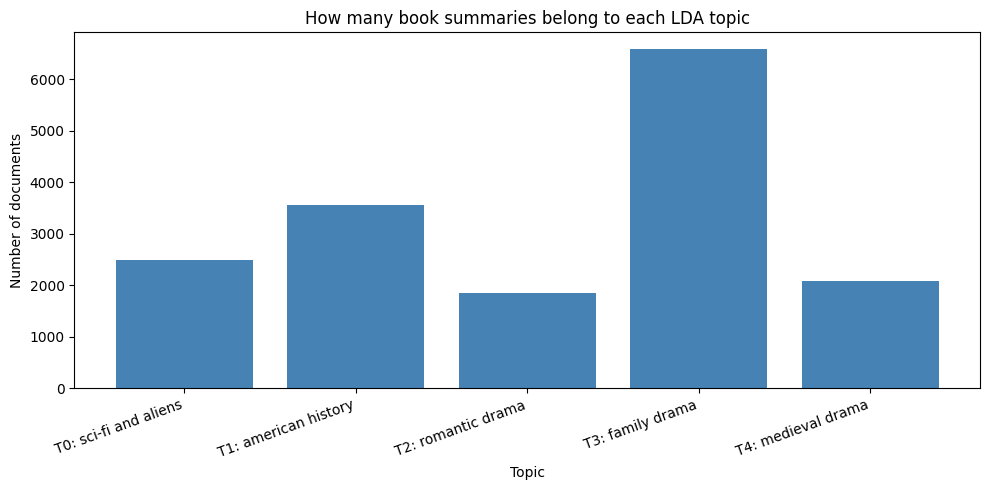

In [11]:
# ---- TODO 9: Bar chart showing how many documents fall in each topic ----

topic_counts = df["dominant_topic"].value_counts()

# Sort by topic ID (so the chart goes 0, 1, 2, 3, 4 in order)
topic_counts = topic_counts.sort_index()

# Build x-axis labels using your topic_labels dictionary from TODO 7
x_labels = []
for topic_id in topic_counts.index:
    x_labels.append(f'T{topic_id}: {topic_labels[topic_id]}')

# Plot
plt.figure(figsize=(10, 5))
plt.bar(x_labels, topic_counts.values, color='steelblue')
plt.xlabel('Topic')
plt.ylabel('Number of documents')
plt.title('How many book summaries belong to each LDA topic')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


👀 **Expected:** A bar chart with 5 bars. The distribution does NOT have to be even.


## Part 7: Coherence Score Comparison (TODO 10) -- 15 pts

How do you know if 5 topics is the right number? Use a **coherence score** to compare different values
of `num_topics` objectively. Higher coherence usually means more interpretable topics.


### TODO 10: Train LDA at multiple topic counts and compare coherence (15 pts)

**Goal:** Train LDA models with `k = [3, 5, 7, 9]` topics. For each model, compute its `c_v` coherence
score. Store the results as a list of `(k, score)` tuples in a variable called `coherence_results`.

**Requirements:**
- Use the same `LdaModel` parameters as TODO 5 (`random_state=42`, `passes=10`)
- Use `gensim.models.coherencemodel.CoherenceModel` with `coherence='c_v'`
- Use a `for` loop over the list of k values
- Print the score after each model is trained


**⚠️ MAJOR PERFORMANCE WARNING:** This cell trains FOUR LDA models on 16K documents.
- We will downsample to 5K but still:
  - **Expected total runtime: 5-7 minutes.**

      - **Use  `workers=4` for Pro or `workers=2` for free versiob.**



In [12]:
# ---- TODO 10: Find the best number of topics using coherence scores ----
#
# A coherence score measures how interpretable a topic is. Higher = better.
# We use 'c_v' coherence, which checks how often the top words of each topic
# co-occur in the original documents. If a topic's top words appear together
# in many documents, the topic is "coherent" (it really represents something).
#
# We don't know the right number of topics ahead of time, so we train LDA
# at several values of k and compare coherence scores. The k with the highest
# score is the best choice.

from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaMulticore

topic_counts_to_try = [3, 5, 7, 9]
coherence_results = []


# Sample 5K documents for the coherence comparison only
sample_size = 5000
sample_indices = np.random.RandomState(42).choice(len(bow_corpus), sample_size, replace=False)
sample_corpus = [bow_corpus[i] for i in sample_indices]
sample_words = [data_words[i] for i in sample_indices]

for k in topic_counts_to_try:
    print(f'Training LDA with k={k} topics...')

    # Train an LDA model with k topics (same params as TODO 5, just swap num_topics)
    # We will use the Muticore version for this
    temp_model = LdaMulticore(
        corpus=sample_corpus,       # ← sample, not full corpus
        id2word=id2word,
        num_topics=k,
        random_state=42,
        passes=10,
        workers=4,  # Change to 2 if you the free version.
    )


    coherence_model = CoherenceModel(
        model=temp_model,
        texts=sample_words,
        dictionary=id2word,
        coherence='c_v',
    )

    # TODO 11b: Get the coherence score from the coherence_model
    # Hint: there's a method called get_coherence()
    score = coherence_model.get_coherence()

    coherence_results.append((k, score))
    print(f'  k={k}: coherence = {score:.4f}')

print('\nDone! Highest score wins.')

# TODO 11c: Find the (k, score) pair with the highest score
# Hint: max(coherence_results, key=lambda pair: pair[1]) returns the winning pair
best_k, best_score = max(coherence_results, key=lambda pair: pair[1])
print(f'\nBest number of topics: k={best_k} with coherence={best_score:.4f}')

Training LDA with k=3 topics...
  k=3: coherence = 0.2901
Training LDA with k=5 topics...
  k=5: coherence = 0.3137
Training LDA with k=7 topics...
  k=7: coherence = 0.3149
Training LDA with k=9 topics...
  k=9: coherence = 0.3059

Done! Highest score wins.

Best number of topics: k=7 with coherence=0.3149


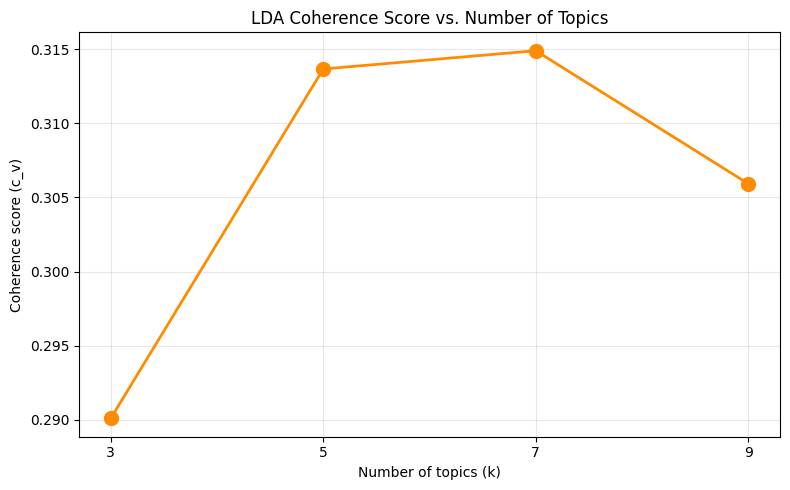


Best number of topics: k=7 with coherence=0.3149


In [13]:
# ---- Plot the comparison (provided -- run as-is) ----
ks = []
scores = []
for k, score in coherence_results:
    ks.append(k)
    scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(ks, scores, marker='o', linewidth=2, markersize=10, color='darkorange')
plt.xlabel('Number of topics (k)')
plt.ylabel('Coherence score (c_v)')
plt.title('LDA Coherence Score vs. Number of Topics')
plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_pair = max(coherence_results, key=lambda pair: pair[1])
print(f'\nBest number of topics: k={best_k_pair[0]} with coherence={best_k_pair[1]:.4f}')


👀 **Expected:** A line chart showing how coherence changes as you add more topics. Coherence usually
peaks somewhere in the middle and then drops if you add too many topics. **Save the best k -- you will
reference it in your reflection.**


## Part 8: Interactive Visualization with pyLDAvis (TODO 11) -- 10 pts

Reading topic words in a list is fine, but **pyLDAvis** lets you explore topics visually -- click
circles, see which topics are similar, drag the lambda slider, and identify the most distinctive
words for each topic.


### TODO 11: Generate the pyLDAvis visualization (10 pts)

**Goal:** Create an interactive pyLDAvis visualization of your `lda_model` from Part 4.

**Hint:** The import is provided for you below (it has a `try/except` because the module name changes
between pyLDAvis versions). You need to call `gensimvis.prepare()` with the right arguments and store
the result in a variable called `lda_vis`. The last line of the cell should be `lda_vis` so the chart
renders inline.


In [14]:
# ---- TODO 11: pyLDAvis interactive visualization ----
import pyLDAvis

try:
    import pyLDAvis.gensim_models as gensimvis
except ImportError:
    import pyLDAvis.gensim as gensimvis

pyLDAvis.enable_notebook()

lda_vis = gensimvis.prepare(lda_model, bow_corpus, id2word)
lda_vis


# ---- End TODO 11 ----


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.039540 -0.109715       1        1  34.277743
1     -0.194110 -0.018947       2        1  19.581950
0      0.013504  0.114488       3        1  18.025645
4      0.058964  0.088570       4        1  14.489911
2      0.082103 -0.074396       5        1  13.624751, topic_info=        Term         Freq        Total Category  logprob  loglift
1644    ship  4343.000000  4343.000000  Default  30.0000  30.0000
2334    king  3982.000000  3982.000000  Default  29.0000  29.0000
1754    love  6424.000000  6424.000000  Default  28.0000  28.0000
753   father  9641.000000  9641.000000  Default  27.0000  27.0000
1760  mother  8240.000000  8240.000000  Default  26.0000  26.0000
...      ...          ...          ...      ...      ...      ...
118   friend   746.385610  4964.608650   Topic5  -6.3429   0.0984
160     like   742.136720  4792.325419   Topic5  -6.3486   0.1280
175    named   726.134269  5080.414382   Topic5  -6.3704   0.0479
1270    must   715.862269  4024.717256   Topic5  -6.3847   0.2666
737      end   701.431326  4690.517807   Topic5  -6.4050   0.0931

[478 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
953        1  0.209244     able
953        2  0.130394     able
953        3  0.294537     able
953        4  0.231028     able
953        5  0.134689     able
...      ...       ...      ...
6375       4  0.001092     york
6375       5  0.009829     york
23191      4  0.988977  yuuzhan
11907      2  0.988203     zinc
30995      5  0.999432     zoey

[1225 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 1, 5, 3])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


👀 **Expected:** An interactive chart with circles on the left (one per topic) and a bar chart on
the right (top words for the selected topic). Click each circle to explore.

💡 **Tip:** Try setting the lambda slider to **0.6** -- this is the recommended balance between
frequent and distinctive words.


## Part 9: Reflection Questions -- 5 pts

Answer each question in **2-3 sentences** in the markdown cell below. Be specific -- reference the
topic words, your coherence chart, and your pyLDAvis visualization.

1. **Topic interpretation:** Look at the top words for each of your 5 topics. Did LDA discover meaningful
themes? Which topic was easiest to label, and which was hardest? Why?

2. **Coherence score:** What was the best `k` according to the coherence chart? Does it match what you
expected? Why might 5 topics not be the best number for book summaries?

3. **pyLDAvis insights:** Use the pyLDAvis chart to find **two topics that are very close together**
(circles overlap). What do their top words have in common? Why might LDA think they are similar?

4. **What would you change?** If you ran this experiment again, what would you change about the
preprocessing, the topic count, or the stopword list to get better topics?

5. **Real-world connection:** How could topic modeling on book summaries be useful to a real business
(publisher, library, online bookstore, recommendation engine)? Give one concrete example.


**Your answers:**

1. I do think that the LDA discovered meaningful themes in each story, as the words produced made it easy to name the topics. It was easiest to name topic 4, "medieval drama", because the top words were very characteristic popular pieces. I immediately envisioned things like Game of Thrones or Lord of the Rings due to the very unique words. The hardest to name was topic 2, "romantic drama". Many of the words were similar to topic 3, "family drama', with some ambigious unique words like "king" that led me to classify it with a more fantastical title.

2. The best number of topics according to the k is 7. I would argue that it does match my expectations, since there were so many books that it would be challenging to narrow down topics into only 5. I think the more topics available, the better.

3. Topics 1 and 5 were closest together. Both topics have "family", "father", and "mother" in their top 5 words. Because of the amount of same important words, the LDA things they are similar.

4. I would remove a few more stopwords for more generic storytelling words. Multiple topics included the word "however", and one included the word "part" in their top 10, which are too generic to help assign it a topic.

5. Topic modeling can be useful for a book recommendation engine. Members of a library could enter a book topic of interest into the engine, the engine could run based off an LDA that assigns books to that topic based on the results of the LDA's topic assigning.


---

## Submission checklist

Before submitting, make sure:

- [ ] All 12 TODOs are completed
- [ ] All cells run without errors (Runtime → Restart and run all)
- [ ] All 5 reflection questions in Part 9 are answered
- [ ] You filled in your topic labels in TODO 7
- [ ] The pyLDAvis chart is visible (not just the code)
- [ ] File is renamed to `LastName_FirstName_M07_TopicModeling.ipynb`
